# Check the deconvolution logic for any issues that could create this DG1 enrichment artifact
March 1, 2024

Is there a bug in the deconvolution? Could there be a problem with how the sum of squares is computed?


Could it be the same issue as to why there was difficulty in deconvolving the gene expression data? I wonder because when I deconvolve a vector of ones, the model enriches DG1. But when I deconvolve a vector of 100s, the model deconvolves values around 100 and the small differences are no longer amplified...

In [12]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [215]:
from cc_src.chromatin_model import load_chromatin_model_from_disk

chromatin_dir = 'output/deconvolve_rep1_g006_2024_02_20/chromatin/'
gene_name = 'SSK22'
chromatin_model = load_chromatin_model_from_disk(gene_name, chromatin_dir)

Loading MNase reads for YCR073C/SSK22...Loading chromosome reads: 3
Done.


In [216]:
chromatin_model.create_deconvolution_bins()

In [287]:
chromatin_model.deconvolve(verbose=True)

Deconvolving with gamma=0.006, gamma_prime=0
                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Mar 01 04:30:55 PM: Your problem has 181600 variables, 1 constraints, and 1 parameters.
(CVXPY) Mar 01 04:30:55 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 01 04:30:55 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 01 04:30:55 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Mar 01 04:30:55 PM: Compiling problem (target solver=MOSEK).
(CVXPY) Mar 01 04:30:55 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixS

(CVXPY) Mar 01 04:32:08 PM: 25  1.2e-02  2.5e-02  1.1e-03  3.86e-01   3.817357332e+03   3.817361748e+03   1.2e-02  26.62 
(CVXPY) Mar 01 04:32:09 PM: 26  1.0e-02  2.1e-02  8.5e-04  3.71e-01   3.807106675e+03   3.807110624e+03   1.0e-02  27.04 
(CVXPY) Mar 01 04:32:09 PM: 27  9.3e-03  1.9e-02  7.5e-04  3.47e-01   3.801210267e+03   3.801213986e+03   9.3e-03  27.39 
(CVXPY) Mar 01 04:32:09 PM: 28  8.4e-03  1.7e-02  6.6e-04  3.37e-01   3.795857196e+03   3.795860721e+03   8.4e-03  27.72 
(CVXPY) Mar 01 04:32:10 PM: 29  7.3e-03  1.5e-02  5.5e-04  3.28e-01   3.787715586e+03   3.787718825e+03   7.3e-03  28.18 
(CVXPY) Mar 01 04:32:10 PM: 30  6.4e-03  1.3e-02  4.7e-04  3.20e-01   3.780562261e+03   3.780565276e+03   6.4e-03  28.51 
(CVXPY) Mar 01 04:32:10 PM: 31  5.8e-03  1.2e-02  4.1e-04  3.17e-01   3.774776028e+03   3.774778871e+03   5.8e-03  28.85 
(CVXPY) Mar 01 04:32:11 PM: 32  5.0e-03  9.9e-03  3.4e-04  3.16e-01   3.766134302e+03   3.766136903e+03   5.0e-03  29.18 
(CVXPY) Mar 01 04:32:11 

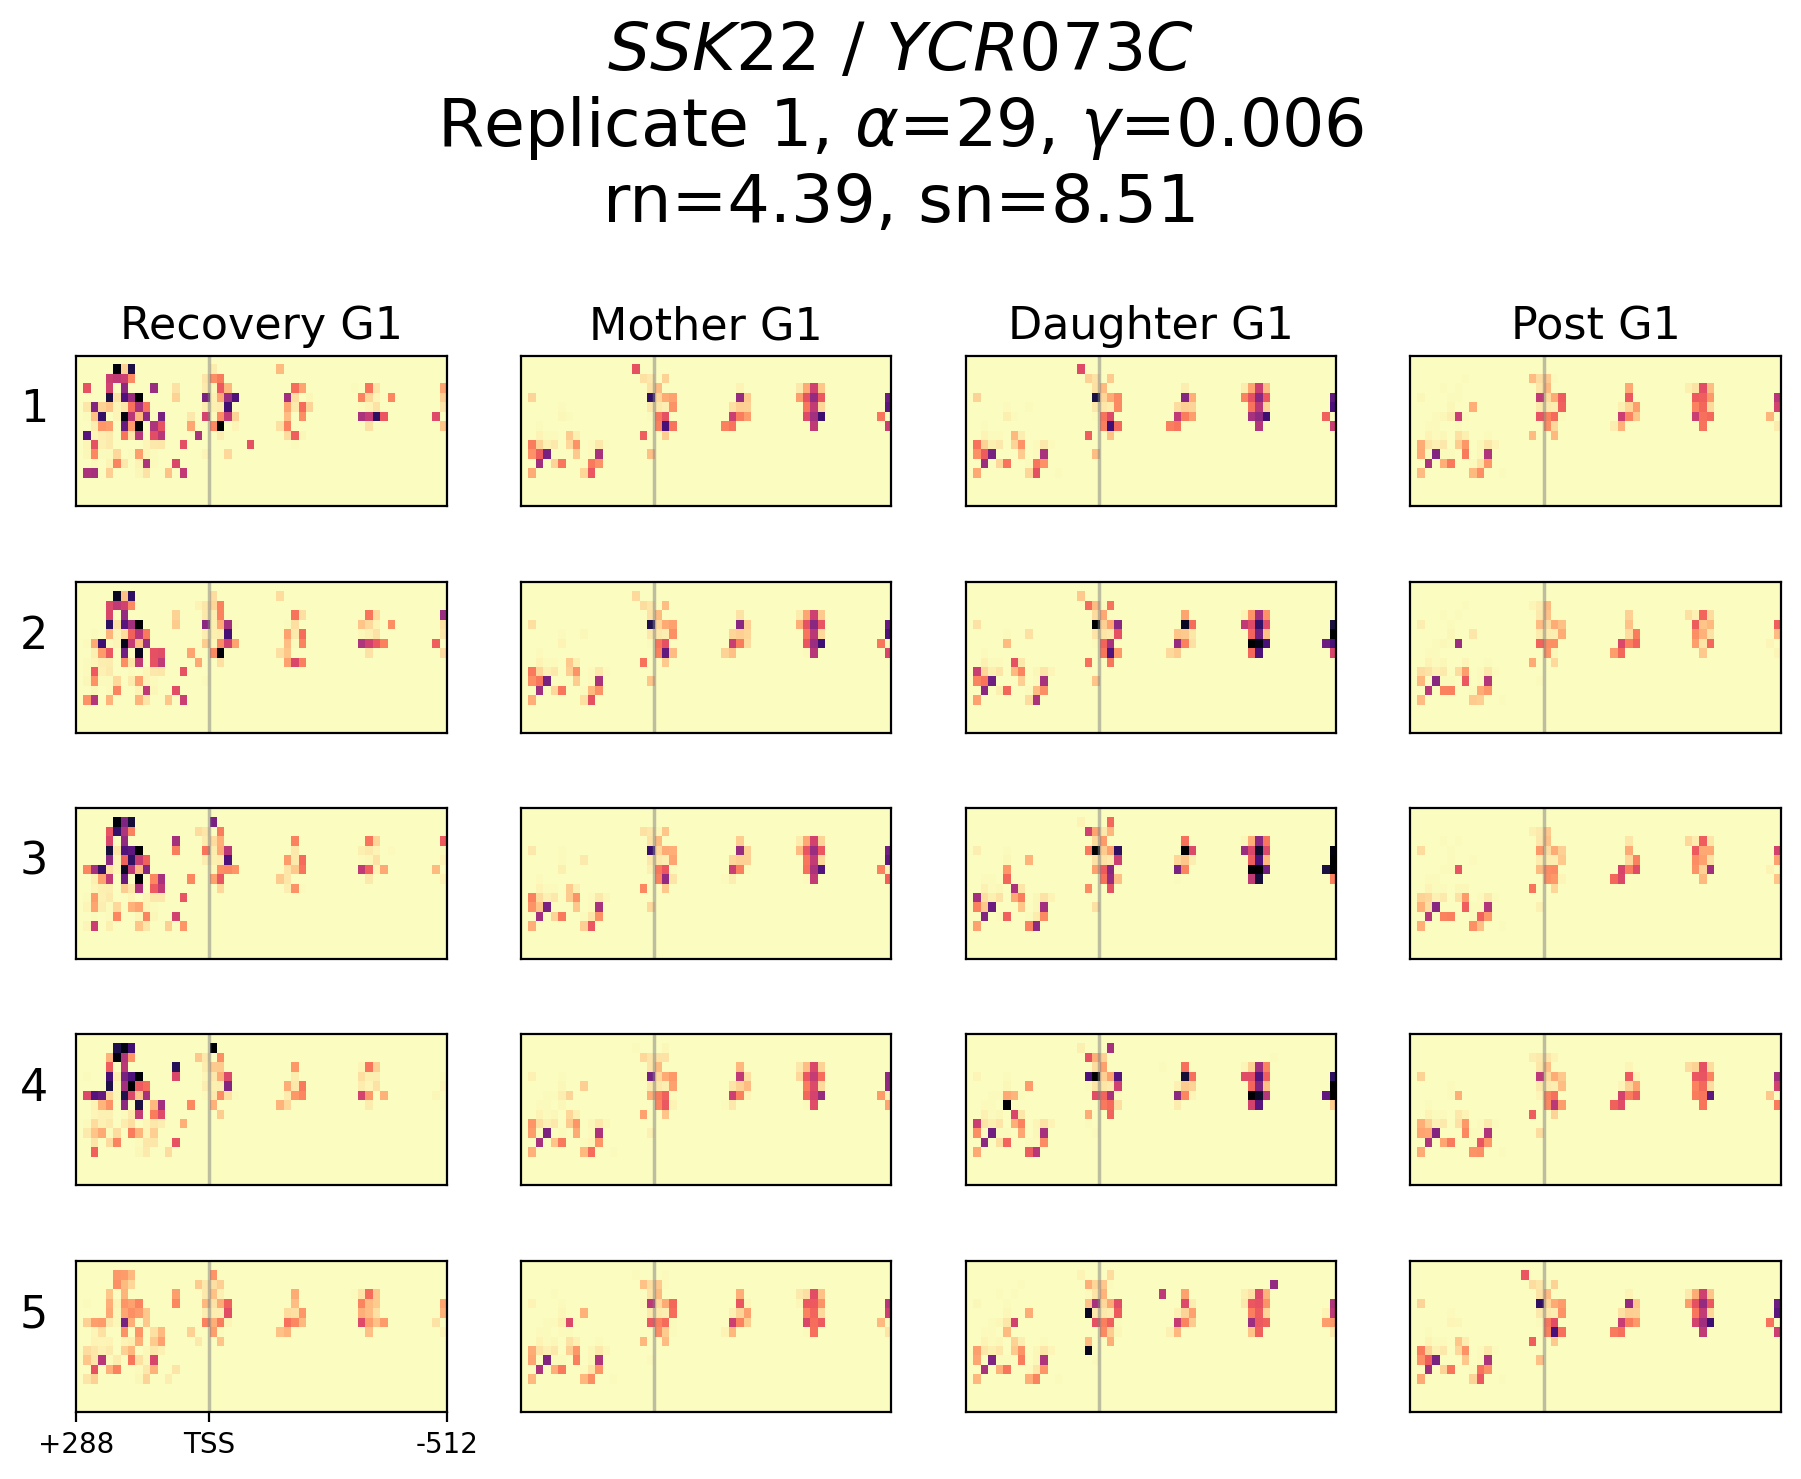

In [289]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped()

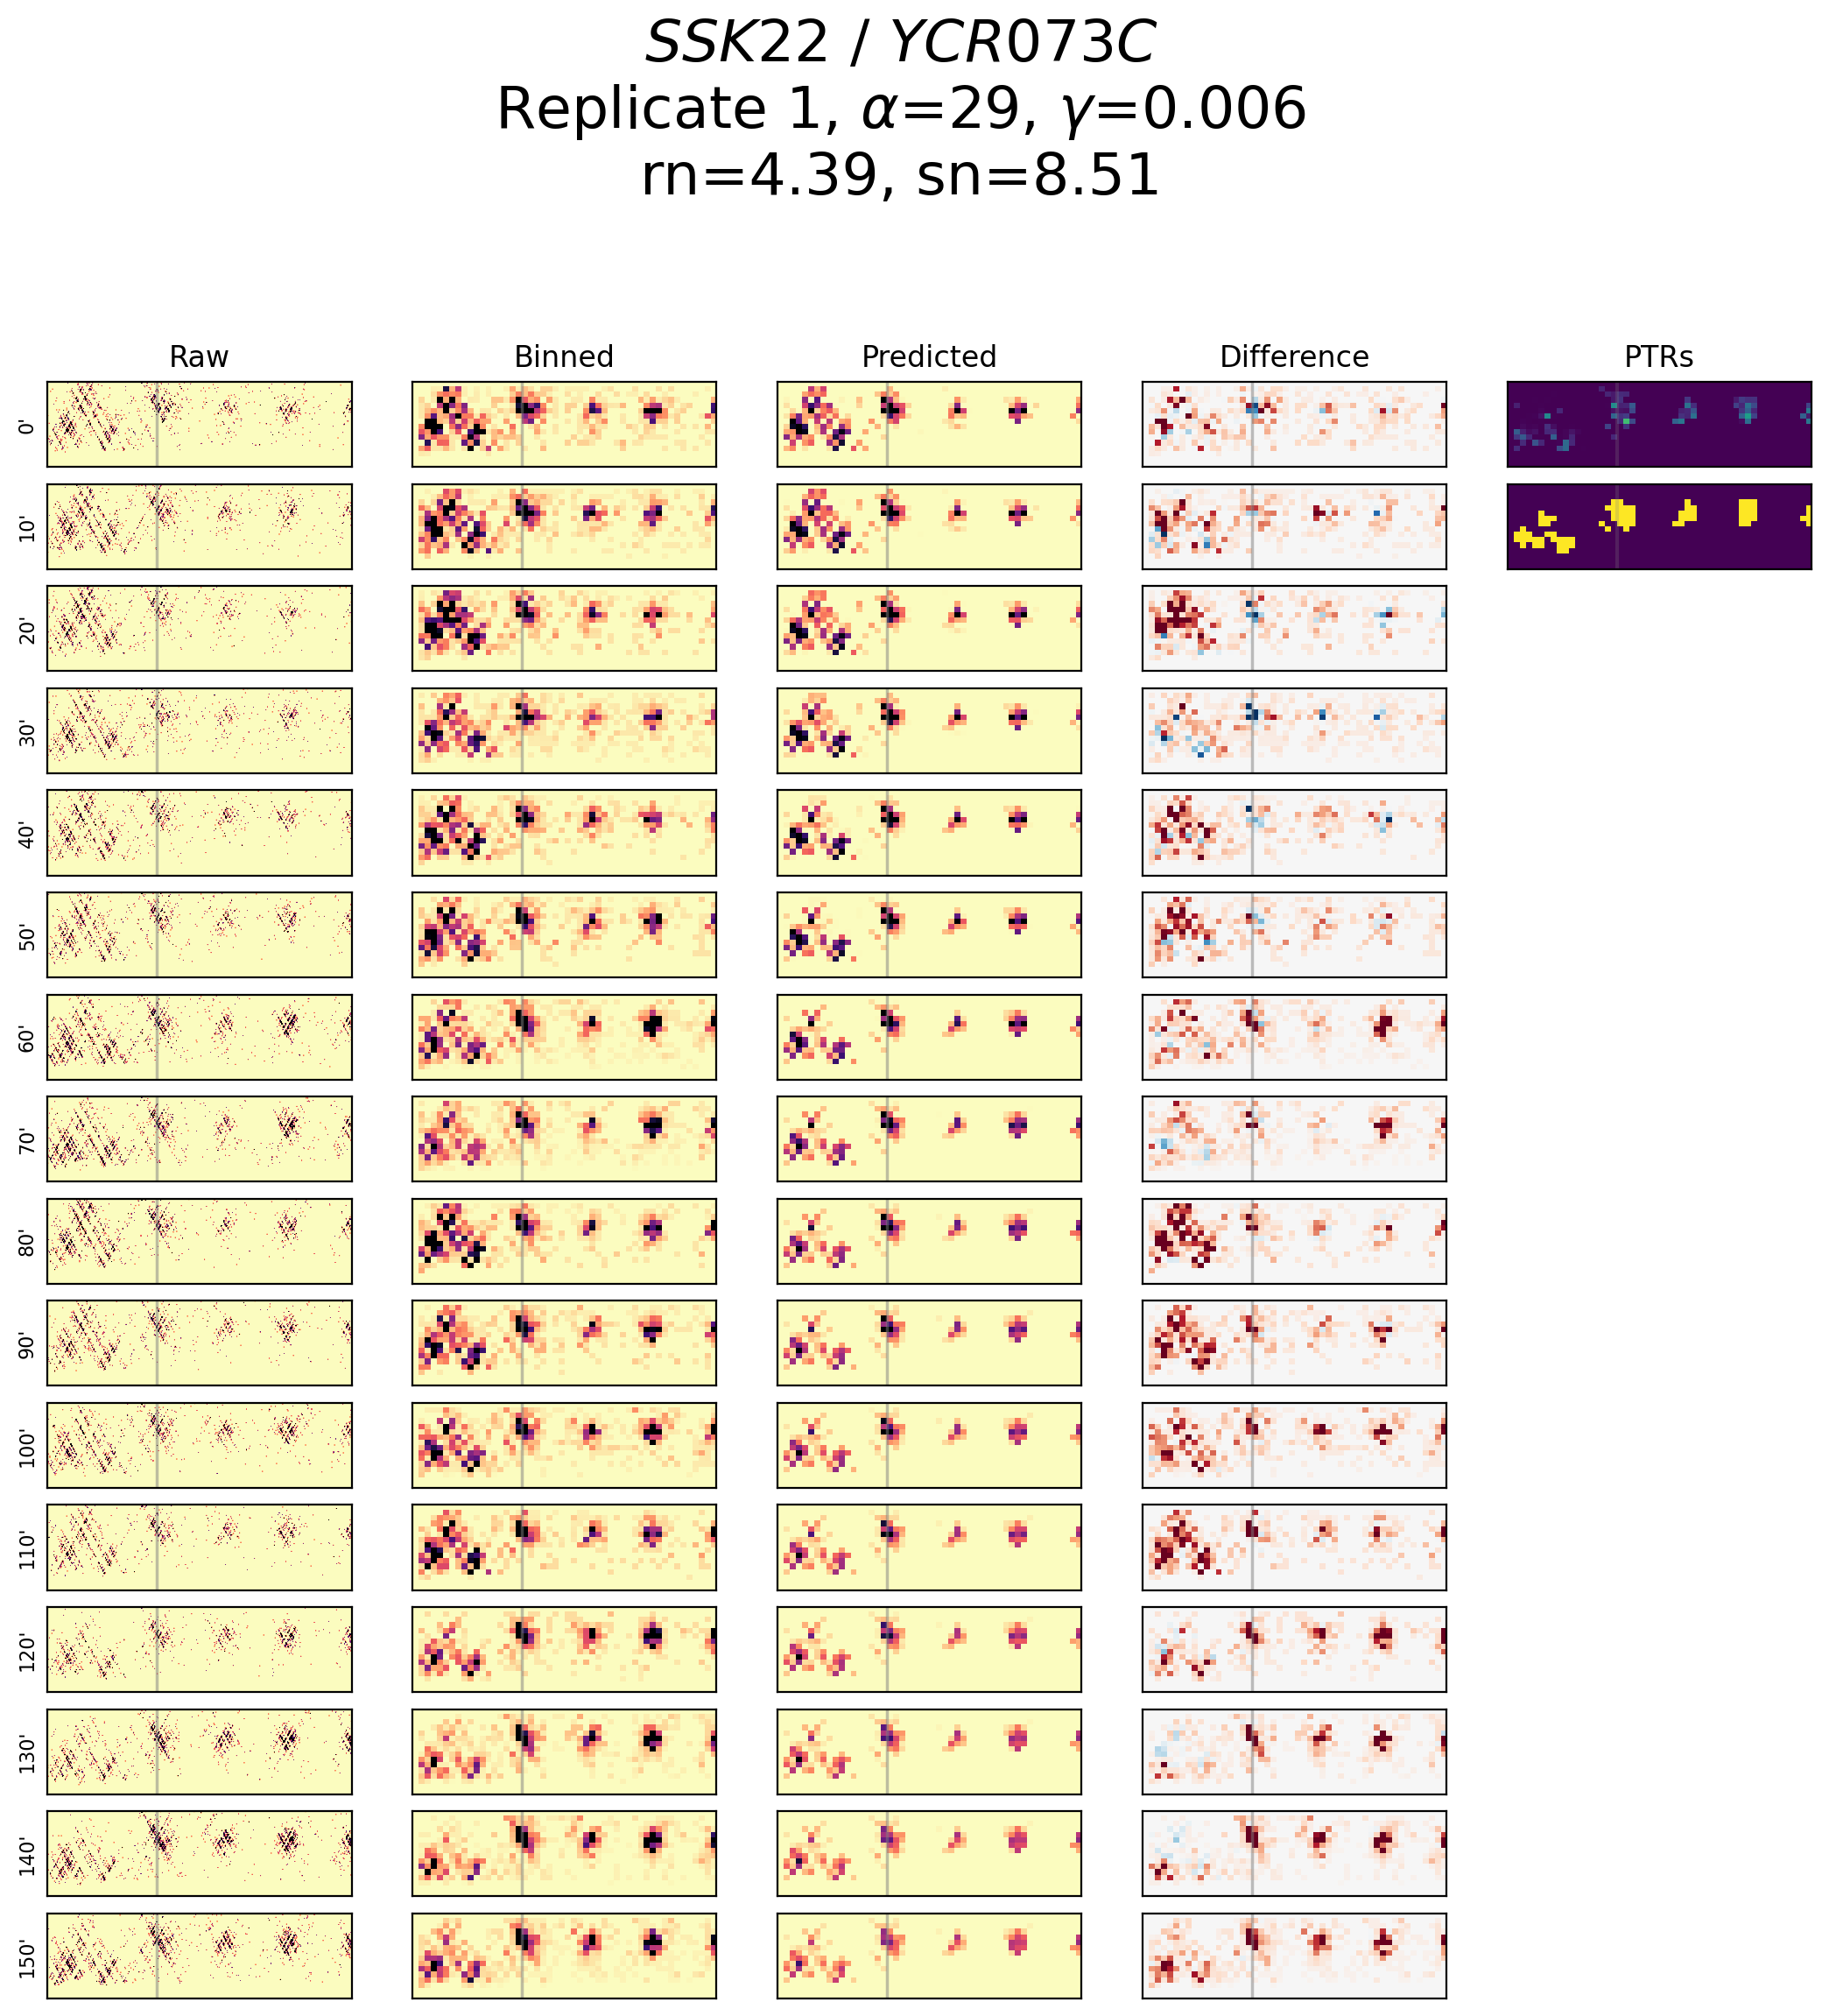

In [291]:
fig = chromatin_model.plot_prediction_comparison()

In [292]:
chromatin_model_preloaded = load_chromatin_model_from_disk(gene_name, chromatin_dir)

Loading MNase reads for YCR073C/SSK22...Loading chromosome reads: 3
Done.


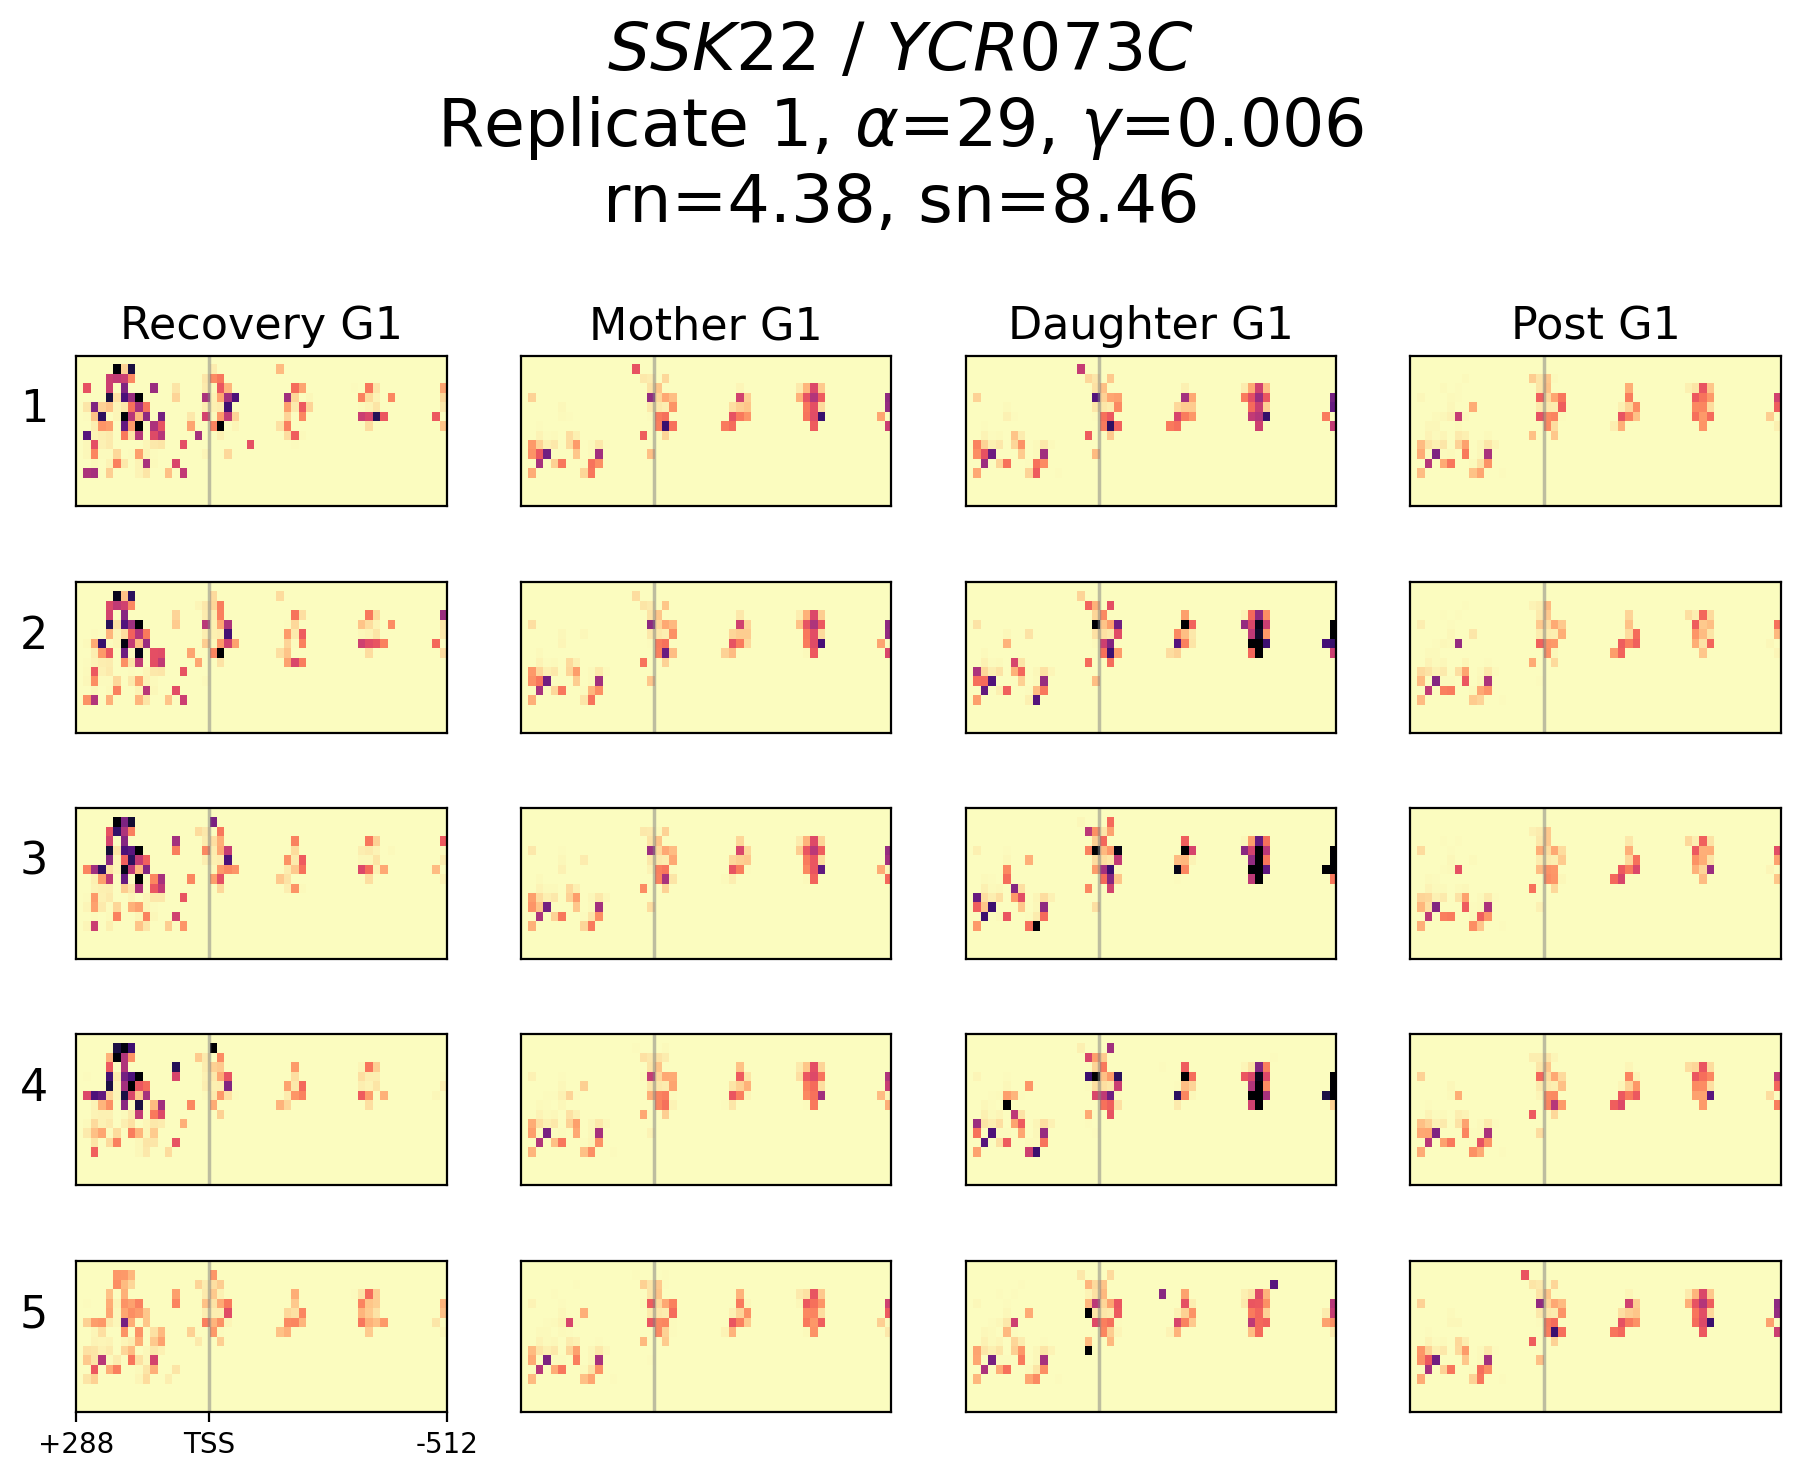

In [294]:
fig = chromatin_model_preloaded.create_deconvolution_plots_abbreviated_flipped()

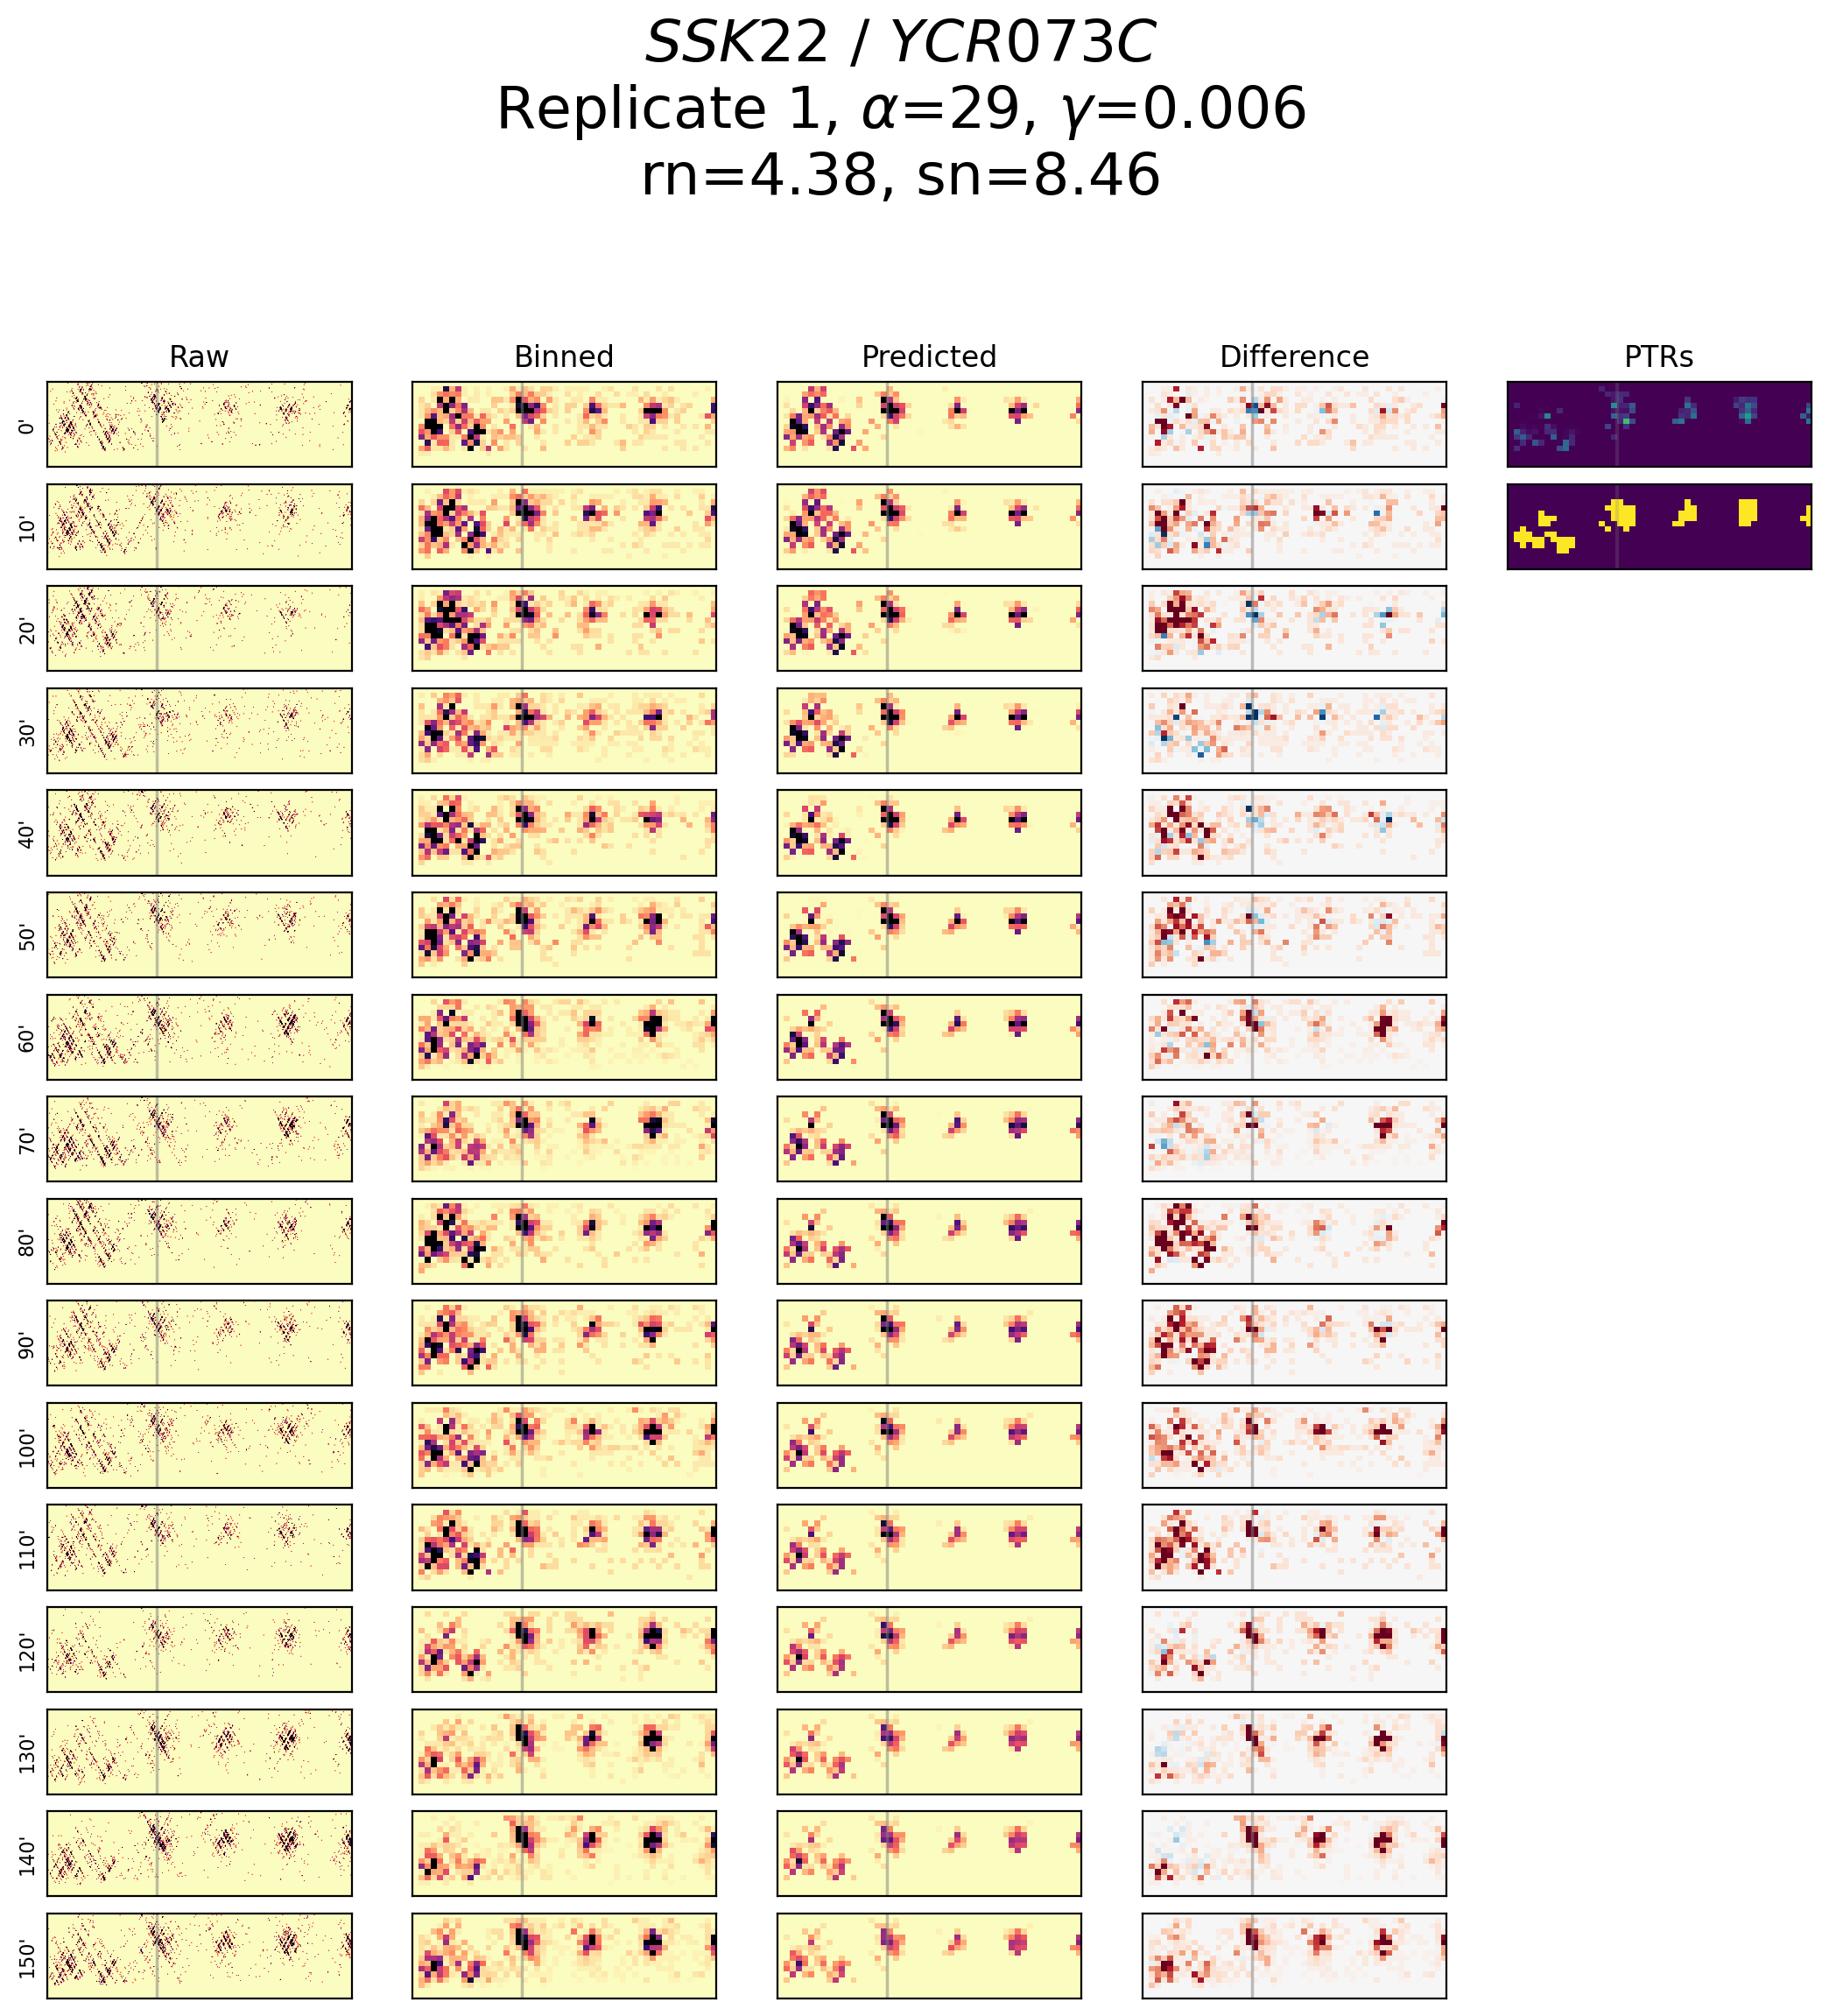

In [297]:
chromatin_model_preloaded.deconvolved_f_value = chromatin_model_preloaded.deconvolved_f_value.reshape((227, -1))
fig = chromatin_model_preloaded.plot_prediction_comparison()

In [284]:
from src.model import Model
from src.dynamic_config_alpha import create_dynamic_alpha_config

config = create_dynamic_alpha_config('data/2019_cloccs_fits/yl_2019_replicate1/posteriors.txt',
                                    alpha=30, replicate=1, name='rep1_test')
deconv_model = Model(config, "SSK22")


In [285]:
i_timepoints = deconv_model.config.get_timepoints_for_branch('i')
t_timepoints = deconv_model.config.get_timepoints_for_branch('t')
b_timepoints = deconv_model.config.get_timepoints_for_branch('b')

i_len = i_timepoints[-1] - i_timepoints[0]
t_len = t_timepoints[-1] - t_timepoints[0]
b_len = b_timepoints[-1] - b_timepoints[0]
i_len, t_len, b_len
(i_len + t_len) / b_len

1.739793440478243

W1 (512, 512)
W2 (256, 256)
f (227, 1)
H (16, 227)


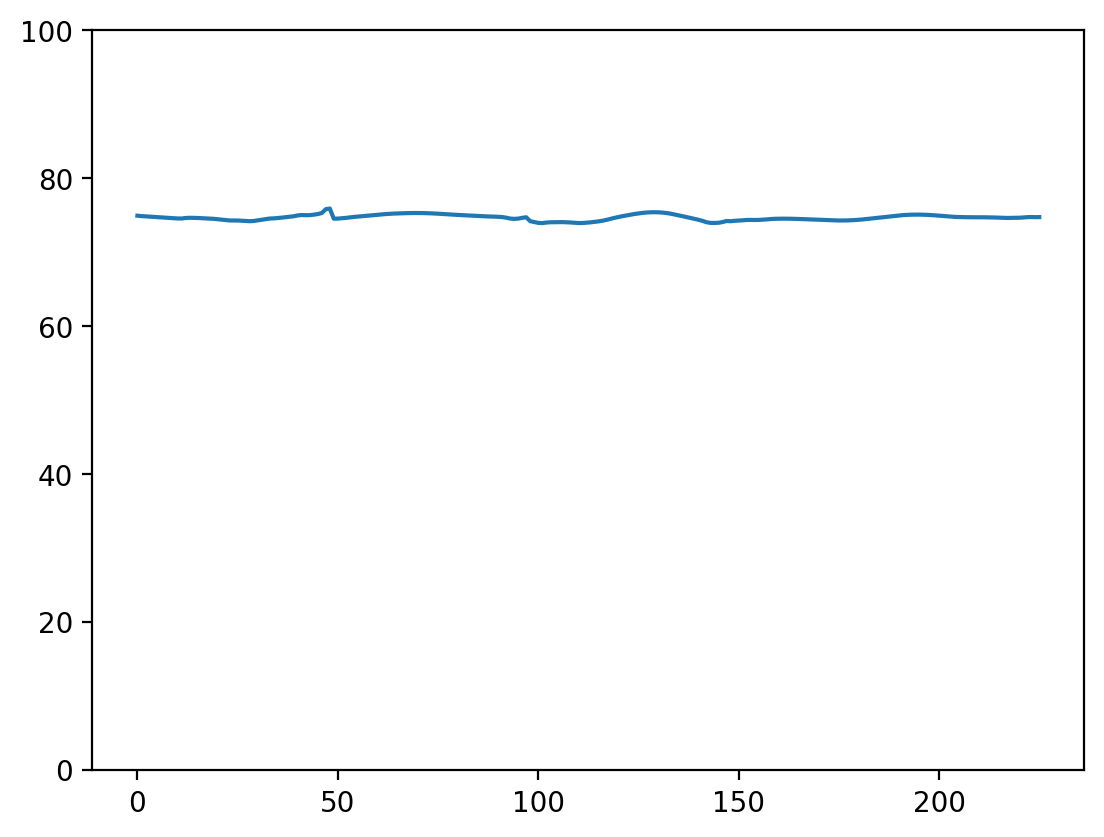

(0.0, 100.0)

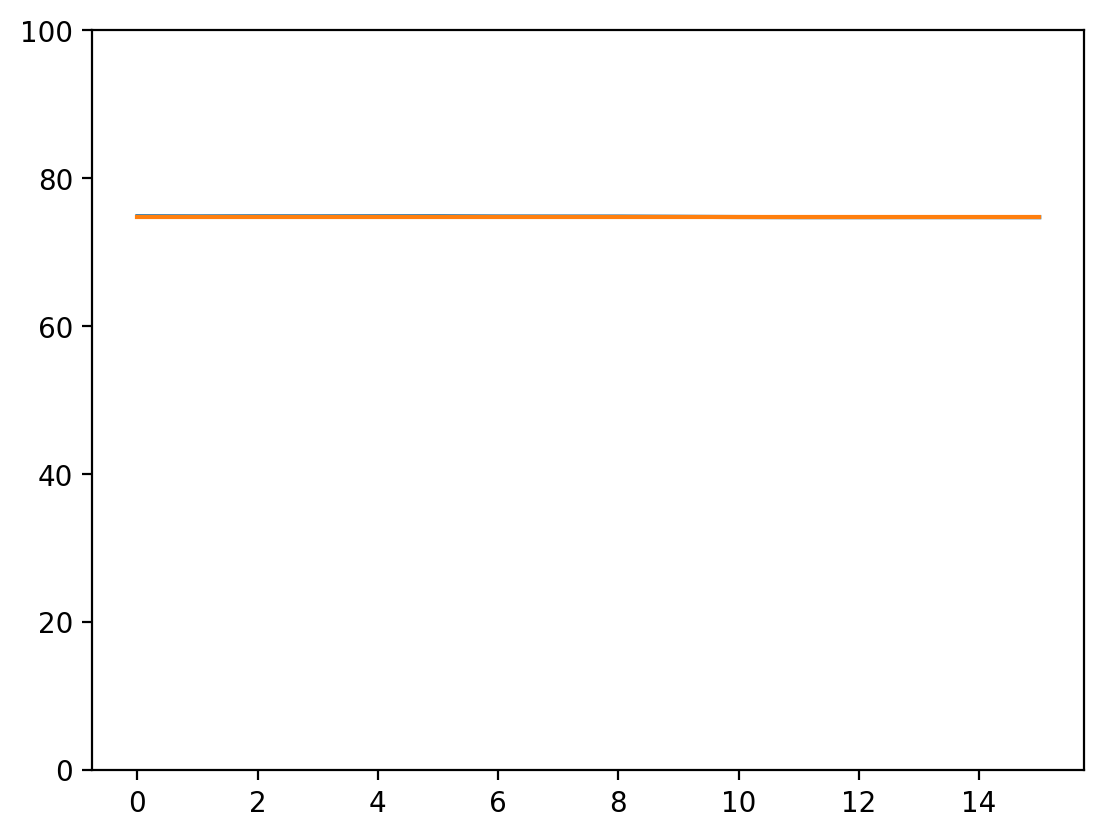

In [286]:
# Maybe we need to normalize by the window to keep the nucleosome count consistent in the window
# prior to deconvolution....
test_G = new_G_imgs[:, row, column].reshape((-1, 1))

deconv_model.gamma = 0.0004
res = deconvolve_chromatin_H(deconv_model, deconv_model.H, test_G)
f = res[0]
plt.plot(f[:-1])
plt.ylim(0, 100)
plt.show()



plt.plot(H@f)
plt.plot(G)
plt.ylim(0, 100)